In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)


In [14]:
train = pd.read_csv('/home/artem_makanov/itmo_mlsd/data/train.csv', index_col=0) 
train = train.sample(frac=1.)

X_train = train["text"]
y_train = train["harmful"]

test = pd.read_csv('/home/artem_makanov/itmo_mlsd/data/test.csv') 

X_test = test["text"]
y_test = test["harmful"]



In [15]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        max_features=50_000
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

pipe.fit(X_train, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=50000, min_df=3,
                                 ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1))])

In [16]:
y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


ROC-AUC: 0.57375
PR-AUC: 0.6292992593351003
              precision    recall  f1-score   support

           0       0.53      0.40      0.46        20
           1       0.52      0.65      0.58        20

    accuracy                           0.53        40
   macro avg       0.53      0.53      0.52        40
weighted avg       0.53      0.53      0.52        40

Confusion matrix:
 [[ 8 12]
 [ 7 13]]


In [17]:
vectorizer = pipe.named_steps["tfidf"]
clf = pipe.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = clf.coef_[0]


In [18]:
top_harmful = feature_names[np.argsort(coefs)[-30:]][::-1]
top_benign  = feature_names[np.argsort(coefs)[:30]]

print("Top harmful features:")
for f in top_harmful:
    print(f)

print("\nTop benign features:")
for f in top_benign:
    print(f)


Top harmful features:
their
you
and
just
in
your
more
this
on
with
was
of the
me
man
will
if
the
is
like
be
to be
of
they
about
it was
would
how
who
have
when

Top benign features:
that
it
to
from
we
or
were
for
at
after
when
have
who
how
would
it was
about
they
of
to be
be
like
is
the
if
will
man
me
of the
was


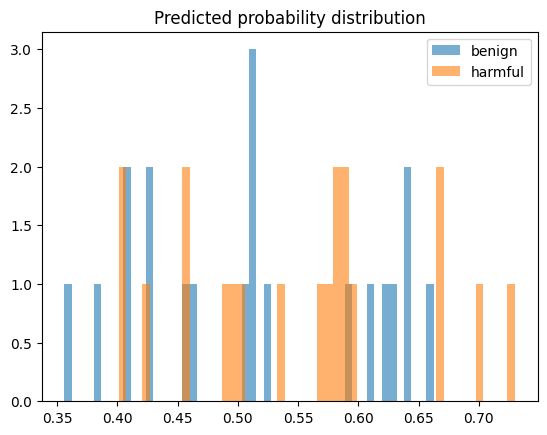

In [19]:
import matplotlib.pyplot as plt

plt.hist(y_proba[y_test == 0], bins=50, alpha=0.6, label="benign")
plt.hist(y_proba[y_test == 1], bins=50, alpha=0.6, label="harmful")
plt.legend()
plt.title("Predicted probability distribution")
plt.show()
